In [19]:
import pandas as pd
df = pd.read_csv("data/processed/processed_df.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [20]:
df.shape

(7032, 20)

In [21]:
# --- Billing / Value features ---
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'].replace(0, 1))
df['charge_gap'] = df['MonthlyCharges'] - df['avg_monthly_spend']
df['is_high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,charge_gap,is_high_value
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,0.000000,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,1.376471,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,-0.225000,0
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,1.394444,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,-5.125000,1


In [23]:
# --- Tenure band (categorical) ---
df['tenure_band'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['0-12', '12-36', '36+'],
    right=True
)
df['tenure_band'] = df['tenure_band'].astype(str)

In [24]:
df.groupby('tenure_band')['Churn'].mean()

tenure_band
0-12     0.476782
12-36    0.255388
36+      0.119294
Name: Churn, dtype: float64

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,is_high_value,tenure_band,streaming_count,security_count,month_to_month_paperless,payment_electronic_check,no_support_services,is_isolated,fiber_no_security,no_internet_services
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,...,0,0-12,0,1,1,1,1,0,0,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,...,0,12-36,0,2,0,0,0,1,0,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,...,0,0-12,0,2,1,0,0,1,0,0
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,...,0,36+,0,3,0,0,0,1,0,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,...,1,0-12,0,0,1,1,1,1,1,0


In [8]:
# --- Service usage counts (numeric) ---
streamning_services = ['StreamingTV','StreamingMovies']
df['streaming_count'] = ((df[streamning_services] == 'Yes') | (df[streamning_services] == 'yes')).sum(axis=1)

security_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['security_count'] = ((df[security_services] == 'Yes') | (df[security_services] == 'yes')).sum(axis=1)   

In [9]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,charge_gap,is_high_value,tenure_band,streaming_count,security_count
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,0,29.850000,0.000000,0,0-12,0,1
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,0,55.573529,1.376471,0,12-36,0,2
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,54.075000,-0.225000,0,0-12,0,2
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,40.905556,1.394444,0,36+,0,3
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,75.825000,-5.125000,1,0-12,0,0


In [10]:
df['month_to_month_paperless'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['PaperlessBilling'] == 'Yes')
).astype(int)

df['payment_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

In [11]:
df.groupby('month_to_month_paperless')['Churn'].mean()

month_to_month_paperless
0    0.139451
1    0.482985
Name: Churn, dtype: float64

In [12]:
df.groupby('payment_electronic_check')['Churn'].mean()

payment_electronic_check
0    0.170988
1    0.452854
Name: Churn, dtype: float64

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,avg_monthly_spend,charge_gap,is_high_value,tenure_band,streaming_count,security_count,month_to_month_paperless,payment_electronic_check
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,0,29.850000,0.000000,0,0-12,0,1,1,1
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,...,1889.50,0,55.573529,1.376471,0,12-36,0,2,0,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,54.075000,-0.225000,0,0-12,0,2,1,0
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,...,1840.75,0,40.905556,1.394444,0,36+,0,3,0,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,...,151.65,1,75.825000,-5.125000,1,0-12,0,0,1,1


In [14]:
    # --- Vulnerability / persona flags (numeric) ---
df['no_support_services'] = ((df['TechSupport'] == 'No') &(df['OnlineSecurity'] == 'No')).astype(int)
    
df['is_isolated'] = ((df['Partner'] == 'No') &(df['Dependents'] == 'No')).astype(int)
    
df['fiber_no_security'] = ((df['InternetService'] == 'Fiber optic') &(df['OnlineSecurity'] == 'No')).astype(int)
    
df['no_internet_services'] = (df['InternetService'] == 'No').astype(int)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,is_high_value,tenure_band,streaming_count,security_count,month_to_month_paperless,payment_electronic_check,no_support_services,is_isolated,fiber_no_security,no_internet_services
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,...,0,0-12,0,1,1,1,1,0,0,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,...,0,12-36,0,2,0,0,0,1,0,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,...,0,0-12,0,2,1,0,0,1,0,0
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,...,0,36+,0,3,0,0,0,1,0,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,...,1,0-12,0,0,1,1,1,1,1,0


In [16]:
df.columns,len(df.columns)

(Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
        'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
        'MonthlyCharges', 'TotalCharges', 'Churn', 'avg_monthly_spend',
        'charge_gap', 'is_high_value', 'tenure_band', 'streaming_count',
        'security_count', 'month_to_month_paperless',
        'payment_electronic_check', 'no_support_services', 'is_isolated',
        'fiber_no_security', 'no_internet_services'],
       dtype='object'),
 32)

saving base + engineered features

In [17]:
import os

# create directory if it doesn't exist
os.makedirs("data/processed", exist_ok=True)
# save dataframe
df.to_csv("data/processed/base_plus_engineered.csv", index=False)

choosing segmentation features

In [15]:
# Choose segmentation features (mixed)
segmentation_features = [
    # Demographics (categorical)
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    # Lifecycle (numeric + categorical)
    'tenure', 'tenure_band',
    # Value (numeric)
    'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charge_gap', 'is_high_value',
    # Services (mixed)
    'PhoneService', 'MultipleLines', 'InternetService',
    'streaming_count', 'security_count',
    # Contract / payment (mixed)
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'payment_electronic_check',
    'month_to_month_paperless',
    # Risk flags (numeric)
    'no_support_services', 'is_isolated', 'fiber_no_security',
    'no_internet_services'
]

data_seg = df[segmentation_features].copy()

In [16]:
data_seg.shape

(7032, 25)

saving engineered feature for segementation

In [ ]:
import os

# create directory if it doesn't exist
os.makedirs("data/processed", exist_ok=True)

# save dataframe
data_seg.to_csv("data/processed/segment_modelling_features.csv", index=False)

segmentation modelling

In [18]:
pd.set_option('display.max_columns', None)

In [ ]:
data_seg = pd.read_csv("data/processed/for_segment_modelling.csv")
data_seg.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,tenure_band,MonthlyCharges,TotalCharges,avg_monthly_spend,charge_gap,is_high_value,PhoneService,MultipleLines,InternetService,streaming_count,security_count,Contract,PaperlessBilling,PaymentMethod,payment_electronic_check,month_to_month_paperless,no_support_services,is_isolated,fiber_no_security,no_internet_services
0,Female,no,Yes,No,1,0-12,29.85,29.85,29.850000,0.000000,0,No,No phone service,DSL,0,1,Month-to-month,Yes,Electronic check,1,1,1,0,0,0
1,Male,no,No,No,34,12-36,56.95,1889.50,55.573529,1.376471,0,Yes,No,DSL,0,2,One year,No,Mailed check,0,0,0,1,0,0
2,Male,no,No,No,2,0-12,53.85,108.15,54.075000,-0.225000,0,Yes,No,DSL,0,2,Month-to-month,Yes,Mailed check,0,1,0,1,0,0
3,Male,no,No,No,45,36+,42.30,1840.75,40.905556,1.394444,0,No,No phone service,DSL,0,3,One year,No,Bank transfer (automatic),0,0,0,1,0,0
4,Female,no,No,No,2,0-12,70.70,151.65,75.825000,-5.125000,1,Yes,No,Fiber optic,0,0,Month-to-month,Yes,Electronic check,1,1,1,1,1,0


In [20]:
data_seg.dtypes

gender                       object
SeniorCitizen                object
Partner                      object
Dependents                   object
tenure                        int64
tenure_band                  object
MonthlyCharges              float64
TotalCharges                float64
avg_monthly_spend           float64
charge_gap                  float64
is_high_value                 int64
PhoneService                 object
MultipleLines                object
InternetService              object
streaming_count               int64
security_count                int64
Contract                     object
PaperlessBilling             object
PaymentMethod                object
payment_electronic_check      int64
month_to_month_paperless      int64
no_support_services           int64
is_isolated                   int64
fiber_no_security             int64
no_internet_services          int64
dtype: object

In [21]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges","avg_monthly_spend","charge_gap","streaming_count","security_count"]
cat_cols = [c for c in data_seg.columns if c not in num_cols]

num_cols, cat_cols

(['tenure',
  'MonthlyCharges',
  'TotalCharges',
  'avg_monthly_spend',
  'charge_gap',
  'streaming_count',
  'security_count'],
 ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure_band',
  'is_high_value',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'payment_electronic_check',
  'month_to_month_paperless',
  'no_support_services',
  'is_isolated',
  'fiber_no_security',
  'no_internet_services'])

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_seg[num_cols] = scaler.fit_transform(data_seg[num_cols])

In [23]:
data_seg.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,tenure_band,MonthlyCharges,TotalCharges,avg_monthly_spend,charge_gap,is_high_value,PhoneService,MultipleLines,InternetService,streaming_count,security_count,Contract,PaperlessBilling,PaymentMethod,payment_electronic_check,month_to_month_paperless,no_support_services,is_isolated,fiber_no_security,no_internet_services
0,Female,no,Yes,No,-1.280248,0-12,-1.161694,-0.994194,-1.157889,0.000465,0,No,No phone service,DSL,-0.906251,-0.206314,Month-to-month,Yes,Electronic check,1,1,1,0,0,0
1,Male,no,No,No,0.064303,12-36,-0.260878,-0.173740,-0.305658,0.526643,0,Yes,No,DSL,-0.906251,0.571179,One year,No,Mailed check,0,0,0,1,0,0
2,Male,no,No,No,-1.239504,0-12,-0.363923,-0.959649,-0.355305,-0.085545,0,Yes,No,DSL,-0.906251,0.571179,Month-to-month,Yes,Mailed check,0,1,0,1,0,0
3,Male,no,No,No,0.512486,36+,-0.747850,-0.195248,-0.791614,0.533513,0,No,No phone service,DSL,-0.906251,1.348672,One year,No,Bank transfer (automatic),0,0,0,1,0,0
4,Female,no,No,No,-1.239504,0-12,0.196178,-0.940457,0.365282,-1.958649,1,Yes,No,Fiber optic,-0.906251,-0.983807,Month-to-month,Yes,Electronic check,1,1,1,1,1,0


In [24]:
for c in cat_cols:
    data_seg[c] = data_seg[c].astype(str)

cat_idx = [data_seg.columns.get_loc(c) for c in cat_cols]
cat_idx

[0, 1, 2, 3, 5, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23, 24]

In [25]:
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt

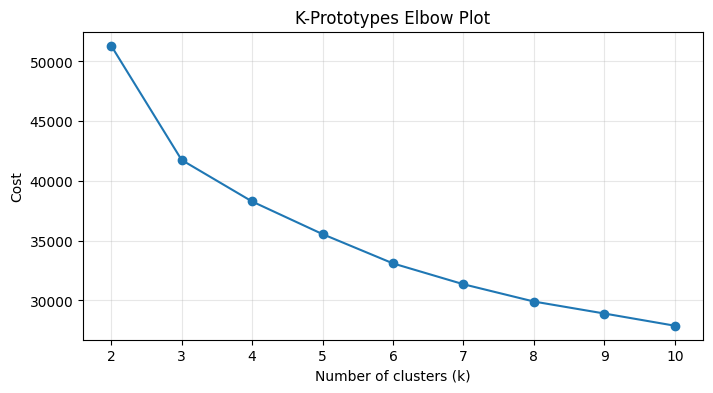

In [27]:
X = data_seg.to_numpy()
costs = []
ks = range(2, 11)

for k in ks:
    kproto = KPrototypes(n_clusters=k, init="Cao", n_init=5, verbose=0, random_state=42)
    labels = kproto.fit_predict(X, categorical=cat_idx)
    costs.append(kproto.cost_)

plt.figure(figsize=(8, 4))
plt.plot(list(ks), costs, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost")
plt.title("K-Prototypes Elbow Plot")
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
final_k = 4

kproto = KPrototypes(
    n_clusters=final_k,
    init="Cao",
    n_init=10,
    verbose=0,
    random_state=42
)

cluster_labels = kproto.fit_predict(X, categorical=cat_idx)
data_seg["segment"] = cluster_labels


In [30]:
data_seg['segment'].value_counts()

segment
1    2099
3    1951
0    1697
2    1285
Name: count, dtype: int64

In [35]:
data_seg.shape

(7032, 26)

adding labels to the actual processed data

In [34]:
import pandas as pd
df = pd.read_csv("data/processed/processed_df.csv")
df.shape

(7032, 20)

In [40]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3


In [36]:
df["segment"] = cluster_labels

In [42]:
segment_summary = df.groupby("segment").agg(
    customers=("segment", "size"),
    churn_rate=("Churn", lambda x: (x == 1).mean()),
    tenure_median=("tenure", "median"),
    monthly_median=("MonthlyCharges", "median"),
    total_median=("TotalCharges", "median")
).sort_values("customers", ascending=False)

segment_summary

,customers,churn_rate,tenure_median,monthly_median,total_median
segment,,,,,
1,2099,0.162935,16.0,20.60,402.60
3,1951,0.562276,10.0,81.10,834.10
0,1697,0.156158,63.0,98.70,5676.65
2,1285,0.128405,38.0,59.75,2203.65


In [43]:
segment_labels = {
    3: "At risk High-value 🚨",
    0: "Loyal High-Value 💎",
    2: "Stable Mid-Value 👍",
    1: "Low Engagement ⚠️"
}

df['segment_label'] = df['segment'].map(segment_labels)

In [44]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨


saving processed data with segment labels

In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/df_with_segment_labels.csv", index=False)